# PM++ On CAMELS

This notebooks presents a comprehensive example of working with CAMELS simulations and using them with either PM++ or PMWD.

### Imports

In [1]:
import os

try:
    os.chdir("/home/r/rouzib/links/projects/aip-lplevass/rouzib/pmpp/")
    local = False
except:
    local = True

print(local)

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "True"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

False


In [2]:
import jax
import hdf5plugin
import readgadget
import numpy as np
from matplotlib import pyplot as plt

import jax
import jax.numpy as jnp

### Reading CAMELS ICs

In this notebook, we are using readgadget by default, but Compute Canada doesn't support readgadget so I previously saved the same information in a npz archive.

In [3]:
snapshot_filename = "CAMELS/ICs/ics"

In [4]:
if local:
    header = readgadget.header(snapshot_filename)
    BoxSize = header.boxsize / 1e3  # Convert box size from kiloparsecs to megaparsecs
    Omega_m = header.omega_m  # Omega_m value
    Omega_l = header.omega_l  # Omega_lambda value
    redshift = header.redshift  # Redshift value at the snapshot

    # Load dark matter properties (particle type 1)
    ptype = [1]
    ids = np.argsort(readgadget.read_block(snapshot_filename, "ID  ", ptype) - 1)
    # Get positions in Mpc/h units and velocities in km/s
    pos = readgadget.read_block(snapshot_filename, "POS ", ptype)[ids] / 1e3
    vel = readgadget.read_block(snapshot_filename, "VEL ", ptype)[ids]
    with jax.default_device(jax.devices("cpu")[0]):
        pos = jnp.array(pos)
        # Recalculate velocities considering cosmological redshift
        vel = jnp.array(vel / 100 * (1.0 / (1 + redshift)))

    mass = (header.massarr[ptype] * 1e10)[0]
else:  # compute canada doesn't support readgadget
    data = np.load("CAMELS/ics.npz", allow_pickle=True)

    pos = data["pos"]
    vel = data["vel"]
    mass = data["mass"].item() if data["mass"].shape == () else data["mass"]
    BoxSize = data["BoxSize"].item() if data["BoxSize"].shape == () else data["BoxSize"]
    Omega_m = data["Omega_m"].item() if data["Omega_m"].shape == () else data["Omega_m"]
    Omega_l = data["Omega_l"].item() if data["Omega_l"].shape == () else data["Omega_l"]
    redshift = data["redshift"].item() if data["redshift"].shape == () else data["redshift"]
    ptype = data["ptype"]
    ids = data["ids"]
    header = data["header"].item()
    snapshot_filename = data["snapshot_filename"].item() if data["snapshot_filename"].shape == () else data[
        "snapshot_filename"]

    with jax.default_device(jax.devices("cpu")[0]):
        pos = jnp.array(pos)
        vel = jnp.array(vel)

### Simulation Parameters

In this example, we run the simulation from redshift $127$ to $0$ with PM steps exclusively. The number of steps is $63$.

In [5]:
print(f"Box size: {BoxSize:.2f} Mpc/h")
print(f"Omega_m: {Omega_m:.2f}")
print(f"Omega_l: {Omega_l:.2f}")
print(f"Redshift: {redshift:.2f}")

Box size: 25.00 Mpc/h
Omega_m: 0.30
Omega_l: 0.70
Redshift: 127.00


In [6]:
ptcl_grid_shape = (256,) * 3
ptcl_spacing = BoxSize / ptcl_grid_shape[0]

z_i = redshift
z_f = 0
a_i = 1 / (1 + z_i)  # initial scale factor
a_f = 1 / (1 + z_f)  # final scale factor
N_steps = 63

### PMWD

Here, we load the ICs and set them up for a PMWD run.

E1009 14:49:05.761251 3332606 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.6.77, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


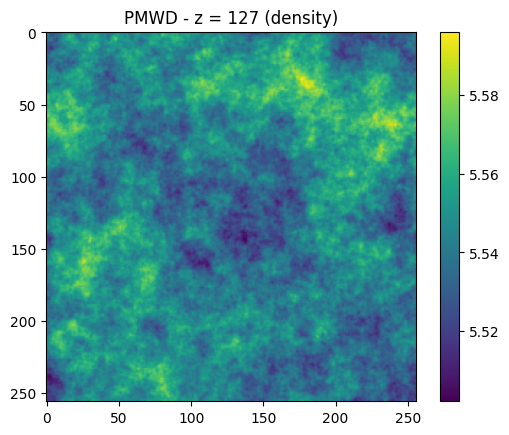

In [7]:
from pmwd import Particles as Particles_pmwd, Configuration as Configuration_pmwd, scatter as scatter_pmwd, SimpleLCDM, \
    boltzmann as boltzmann_pmwd, nbody as nbody_pmwd

conf = Configuration_pmwd(ptcl_spacing, ptcl_grid_shape, mesh_shape=1, a_start=a_i, a_stop=a_f,
                          a_nbody_maxstep=(a_f - a_i) / N_steps)
ptcl = Particles_pmwd.from_pos(conf, pos)
ptcl = ptcl.replace(vel=vel)
cosmo = SimpleLCDM(conf)
cosmo = boltzmann_pmwd(cosmo, conf)

dens = scatter_pmwd(ptcl, conf)
plt.imshow(jnp.log(dens.sum(1)))
plt.colorbar()
plt.title("PMWD - z = 127 (density)")
plt.show()

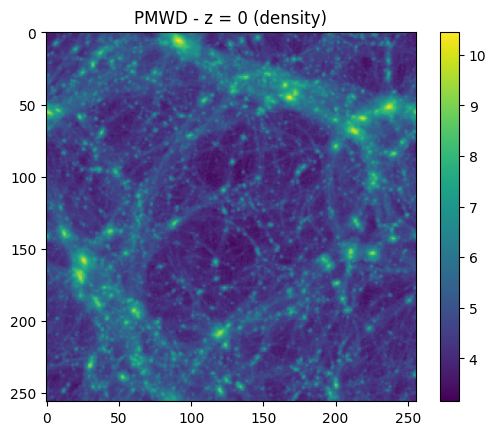

In [8]:
ptcl_final, _ = nbody_pmwd(ptcl, None, cosmo, conf)

dens_pmwd = scatter_pmwd(ptcl_final, conf)
plt.imshow(jnp.log(dens_pmwd.sum(1)))
plt.title("PMWD - z = 0 (density)")
plt.colorbar()

### Loading CAMELS Redshift 0

This is the same code as when loading the ICs, but loading the final snapshot of CAMELS.

In [9]:
snapshot_filename = "CAMELS/snapshot_090"

if local:
    header = readgadget.header(snapshot_filename)
    BoxSize = header.boxsize / 1e3  # Convert box size from kiloparsecs to megaparsecs
    Omega_m = header.omega_m  # Omega_m value
    Omega_l = header.omega_l  # Omega_lambda value
    redshift = header.redshift  # Redshift value at the snapshot

    # Load dark matter properties (particle type 1)
    ptype = [1]
    ids = np.argsort(readgadget.read_block(snapshot_filename, "ID  ", ptype) - 1)
    # Get positions in Mpc/h units and velocities in km/s
    pos_f = readgadget.read_block(snapshot_filename, "POS ", ptype)[ids] / 1e3
    vel_f = readgadget.read_block(snapshot_filename, "VEL ", ptype)[ids]
    pos_f = jnp.array(pos_f)
    # Recalculate velocities considering cosmological redshift
    vel_f = jnp.array(vel_f / 100 * (1.0 / (1 + redshift)))

    mass = (header.massarr[ptype] * 1e10)[0]
else:
    data = np.load("CAMELS/snapshot_090.npz", allow_pickle=True)

    pos_f = data["pos"]
    vel_f = data["vel"]
    mass = data["mass"].item() if data["mass"].shape == () else data["mass"]
    BoxSize = data["BoxSize"].item() if data["BoxSize"].shape == () else data["BoxSize"]
    Omega_m = data["Omega_m"].item() if data["Omega_m"].shape == () else data["Omega_m"]
    Omega_l = data["Omega_l"].item() if data["Omega_l"].shape == () else data["Omega_l"]
    redshift = data["redshift"].item() if data["redshift"].shape == () else data["redshift"]
    ptype = data["ptype"]
    ids = data["ids"]
    header = data["header"].item()
    snapshot_filename = data["snapshot_filename"].item() if data["snapshot_filename"].shape == () else data[
        "snapshot_filename"]

    with jax.default_device(jax.devices("cpu")[0]):
        pos_f = jnp.array(pos_f)
        vel_f = jnp.array(vel_f)

Using PMWD to compute the field.

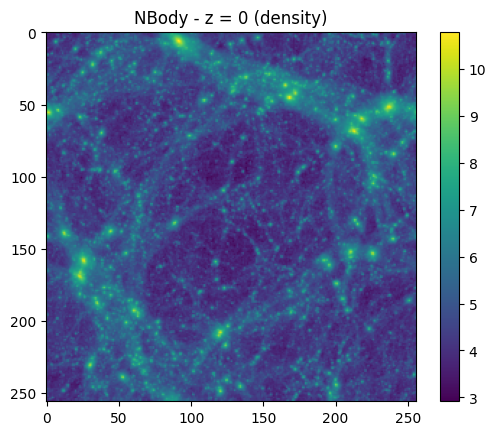

In [10]:
ptcl_temp = Particles_pmwd.from_pos(conf, pos_f)

dens_nbody = scatter_pmwd(ptcl_temp, conf)
plt.imshow(jnp.log(dens_nbody.sum(1)))
plt.title("NBody - z = 0 (density)")
plt.colorbar()

### PM++

PM++ needs a few more parameters than PMWD. These are:
1. `max_ptcl_per_slice`: number of particles on a device. For the code to work with Jit, this quantity needs to be known ahead of time. In this example, the `max_ptcl_per_slice` is setup as a multiplicative factor compared to the optimal number of particles per devices ($1$). For bigger boxes, a smaller fraction would be needed. From tests, $1.35$ seems to work well for $640^3$ particles.
2. `max_share_ptcl`: number of particles that can will be shared at each step. The more steps, the bigger the number of crossing particles becomes. This is usually independent of the number of GPUs used.
3. `max_share_gather_ptcl`: number of particles that is exchanged when computing the `gather` call in the gravity computation. The smaller the mesh size, the bigger this number is.

When the simulation encounters a problem with any of these values, i.e. there is not enough space to either send or receive particles from a GPU to the next, the simulation will print an error message, but will still run. The simulations will have lost particles, but might still look good.

In [11]:
from src.utils import create_compute_mesh
from src.configuration import Configuration
from src.nbody import nbody
from src.scatter import scatter
from src.particles import Particles
from src.cosmo import SimpleLCDM
from src.boltzmann import boltzmann

num_ptcl = 256
num_devices = jax.device_count()
max_ptcl_per_slice = 1.8
max_share_ptcl = 50000
max_share_gather_ptcl = 120000

compute_mesh = create_compute_mesh(jax.devices()[:num_devices])
conf_mGPU = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=1, compute_mesh=compute_mesh, a_start=a_i,
                          a_stop=a_f, a_nbody_maxstep=(a_f - a_i) / N_steps,
                          max_ptcl_per_slice=int(num_ptcl * num_ptcl * num_ptcl / num_devices * max_ptcl_per_slice),
                          max_share_ptcl=max_share_ptcl, max_share_gather_ptcl=max_share_gather_ptcl)

cosmo = SimpleLCDM(conf_mGPU)
cosmo = boltzmann(cosmo, conf_mGPU)

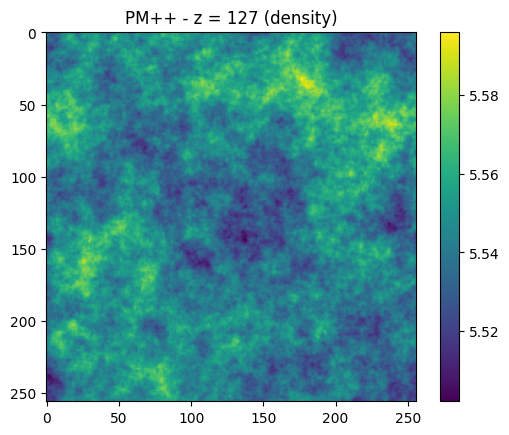

In [12]:
ptcl_mGPU = Particles.from_pos_sharded(conf_mGPU, pos, vel)

dens = scatter(ptcl_mGPU, conf_mGPU)
plt.imshow(jnp.log(dens.sum(1)))
plt.colorbar()
plt.title("PM++ - z = 127 (density)")
plt.show()

In JAX, all multi-GPU code needs to be jitted. Therefore, running non-jitted `nbody` calls and jitted `nbody` in the same code will throw errors. Be sure to only run one or the other exclusively. Usually, the first execution is much slower than the others (~20x) since the shared arrays need to be split and traced through all GPUs.

In [13]:
nbody_jitted_mGPU = jax.jit(nbody, static_argnames=("conf", "reverse"))

In [ ]:
ptcl_final_mGPU = nbody_jitted_mGPU(ptcl_mGPU, cosmo, conf_mGPU)

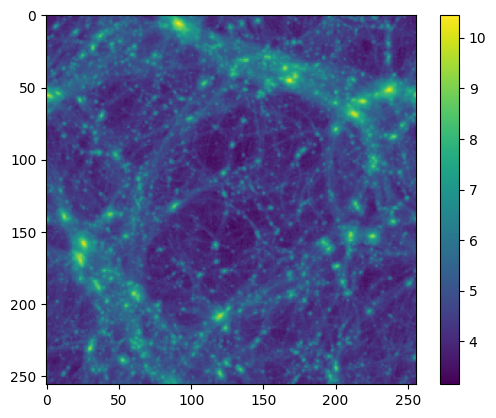

In [15]:
dens_pmpp = scatter(ptcl_final_mGPU, conf_mGPU)
plt.imshow(jnp.log(dens_pmpp.sum(1)))
plt.title("PM++ - z = 0 (density)")
plt.colorbar()

### Simulator Differences

Since PM++_v2 is PMWD based, both simulators give the same results (~with multi-GPU precision errors).

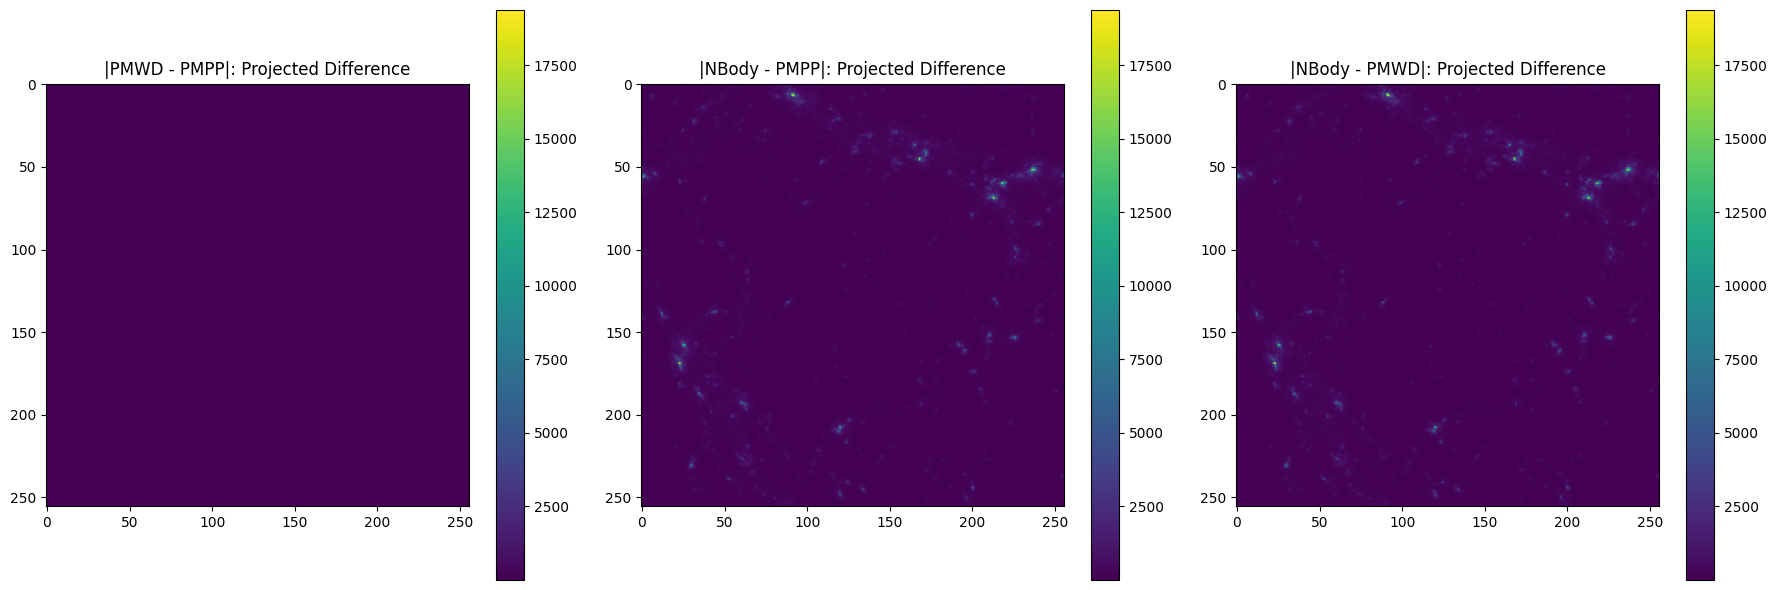

In [20]:
diff_pmwd_pmpp = jnp.abs(dens_pmwd - dens_pmpp).sum(1)
diff_nbody_pmpp = jnp.abs(dens_nbody - dens_pmpp).sum(1)
diff_nbody_pmwd = jnp.abs(dens_nbody - dens_pmwd).sum(1)

vmin = min(diff_pmwd_pmpp.min(), diff_nbody_pmpp.min(), diff_nbody_pmwd.min())
vmax = max(diff_pmwd_pmpp.max(), diff_nbody_pmpp.max(), diff_nbody_pmwd.max())

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

im0 = axs[0].imshow(diff_pmwd_pmpp)
axs[0].set_title('|PMWD - PMPP|: Projected Difference')
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(diff_nbody_pmpp, vmin=vmin, vmax=vmax)
axs[1].set_title('|NBody - PMPP|: Projected Difference')
plt.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(diff_nbody_pmwd, vmin=vmin, vmax=vmax)
axs[2].set_title('|NBody - PMWD|: Projected Difference')
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

### Small example of running 640^3 simulations

Here, we run a $640^3$ particles simulation on $4$ H100. With mesh size of $640^3$ as well, each GPU use ~$27$ GB of memory, such that this same code should fit in 4 A100 40GB. On a single H100, PMWD is able to run the same code, but uses ~$70$ GB of VRAM.

One can see that 27*4 != 70. This is because of the bigger arrays needed per GPU.

In [ ]:
from src.lpt import lpt
from src.modes import white_noise, linear_modes
from src.utils import create_compute_mesh
from src.configuration import Configuration
from src.nbody import nbody
from src.scatter import scatter
from src.particles import Particles
from src.cosmo import SimpleLCDM
from src.boltzmann import boltzmann

seed = 43278543

num_ptcl = 640
box_size = 100  # mpc/h
ptcl_grid_shape = (num_ptcl,) * 3
ptcl_spacing = box_size / ptcl_grid_shape[0]

num_devices = jax.device_count()
max_ptcl_per_slice = 1.35
max_share_ptcl = 350_000
max_share_gather_ptcl = 700_000

# num_ptcl = 1024
# box_size = 1000  # mpc/h
# ptcl_grid_shape = (num_ptcl,) * 3
# ptcl_spacing = box_size / ptcl_grid_shape[0]
#
# num_devices = jax.device_count()
# max_ptcl_per_slice = 1.1
# max_share_ptcl = 100_000
# max_share_gather_ptcl = 2_000_000

compute_mesh = create_compute_mesh(jax.devices()[:num_devices])
conf_mGPU = Configuration(ptcl_spacing=ptcl_spacing,
                          ptcl_grid_shape=ptcl_grid_shape,
                          mesh_shape=1,
                          compute_mesh=compute_mesh,
                          max_ptcl_per_slice=int(num_ptcl * num_ptcl * num_ptcl / num_devices * max_ptcl_per_slice),
                          max_share_ptcl=max_share_ptcl,
                          max_share_gather_ptcl=max_share_gather_ptcl)


def run_sim(conf_mGPU, seed):
    # need to move much more particles during the lpt step, so new configuration for it
    conf_mGPU_lpt = conf_mGPU.replace(max_share_ptcl=700_000)

    cosmo = SimpleLCDM(conf_mGPU)
    cosmo = boltzmann(cosmo, conf_mGPU)

    modes = white_noise(seed, conf_mGPU)
    modes = linear_modes(modes, cosmo, conf_mGPU)
    ptcl_lpt_mGPU = lpt(modes, cosmo, conf_mGPU_lpt)

    nbody_jitted_mGPU = jax.jit(nbody, static_argnames=("conf", "reverse"))
    ptcl_final_mGPU = nbody_jitted_mGPU(ptcl_lpt_mGPU, cosmo, conf_mGPU)

    dens_640 = scatter(ptcl_final_mGPU, conf_mGPU)
    plt.imshow(jnp.log(dens_640.sum(1)))
    plt.title("PM++ 640^3 - z = 0 (density)")
    plt.colorbar()


run_sim(conf_mGPU, seed)

E1009 14:47:11.341808 3330344 ptx_compiler_helpers.cc:88] *** WARNING *** Invoking ptxas with version 12.6.77, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


In [ ]:
run_sim(conf_mGPU, seed + 1)

In [18]:
!nvidia-smi

/cvmfs/soft.computecanada.ca/easybuild/software/2023/x86-64-v4/Compiler/gcccore/python/3.11.5/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Wed Oct  8 16:45:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.20             Driver Version: 570.133.20     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:4E:00.0 Off |                    0 |
| N/A   48C    P0            124W /  700W |   27807MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

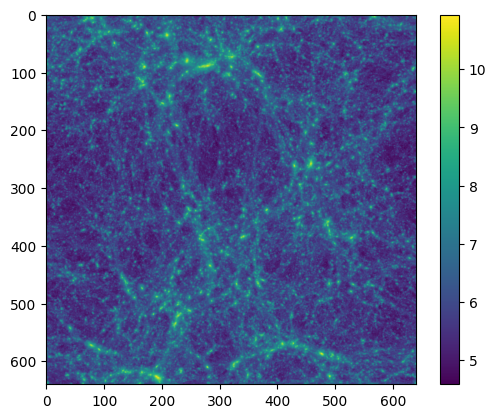

In [19]:
from pmwd import white_noise as white_noise_pmwd, linear_modes as linear_modes_pmwd, lpt as lpt_pmwd
from pmwd import Particles as Particles_pmwd, Configuration as Configuration_pmwd, scatter as scatter_pmwd, SimpleLCDM, \
    boltzmann as boltzmann_pmwd, nbody as nbody_pmwd

seed = 43278543

num_ptcl = 640
box_size = 100  # mpc/h
ptcl_grid_shape = (num_ptcl,) * 3
ptcl_spacing = box_size / ptcl_grid_shape[0]

compute_mesh = create_compute_mesh(jax.devices()[:num_devices])
conf_pmwd = Configuration_pmwd(ptcl_spacing=ptcl_spacing,
                               ptcl_grid_shape=ptcl_grid_shape,
                               mesh_shape=1)

cosmo = SimpleLCDM(conf_pmwd)
cosmo = boltzmann_pmwd(cosmo, conf_pmwd)

modes = white_noise_pmwd(seed, conf_pmwd)
modes = linear_modes_pmwd(modes, cosmo, conf_pmwd)
ptcl_lpt_pmwd, _ = lpt_pmwd(modes, cosmo, conf_pmwd)

ptcl_final_pmwd, _ = nbody_pmwd(ptcl_lpt_pmwd, None, cosmo, conf_pmwd)

dens_640_pmwd = scatter_pmwd(ptcl_final_pmwd, conf_pmwd)
plt.imshow(jnp.log(dens_640_pmwd.sum(1)))
plt.title("PMWD 640^3 - z = 0 (density)")
plt.colorbar()